# EDA

In [1]:
from pathlib import Path
import pandas as pd

# 1. Cari folder kaggle di direktori saat ini atau di atasnya
root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "kaggle").exists()), None)


data = [{"Kelas": f.name, "Jumlah": sum(1 for _ in f.glob("*"))} for f in (root / "kaggle").iterdir() if f.is_dir()]
print(pd.DataFrame(data).to_string(index=False))


       Kelas  Jumlah
Flea_Allergy     241
      Health     245
    Ringworm     247
     Scabies     250


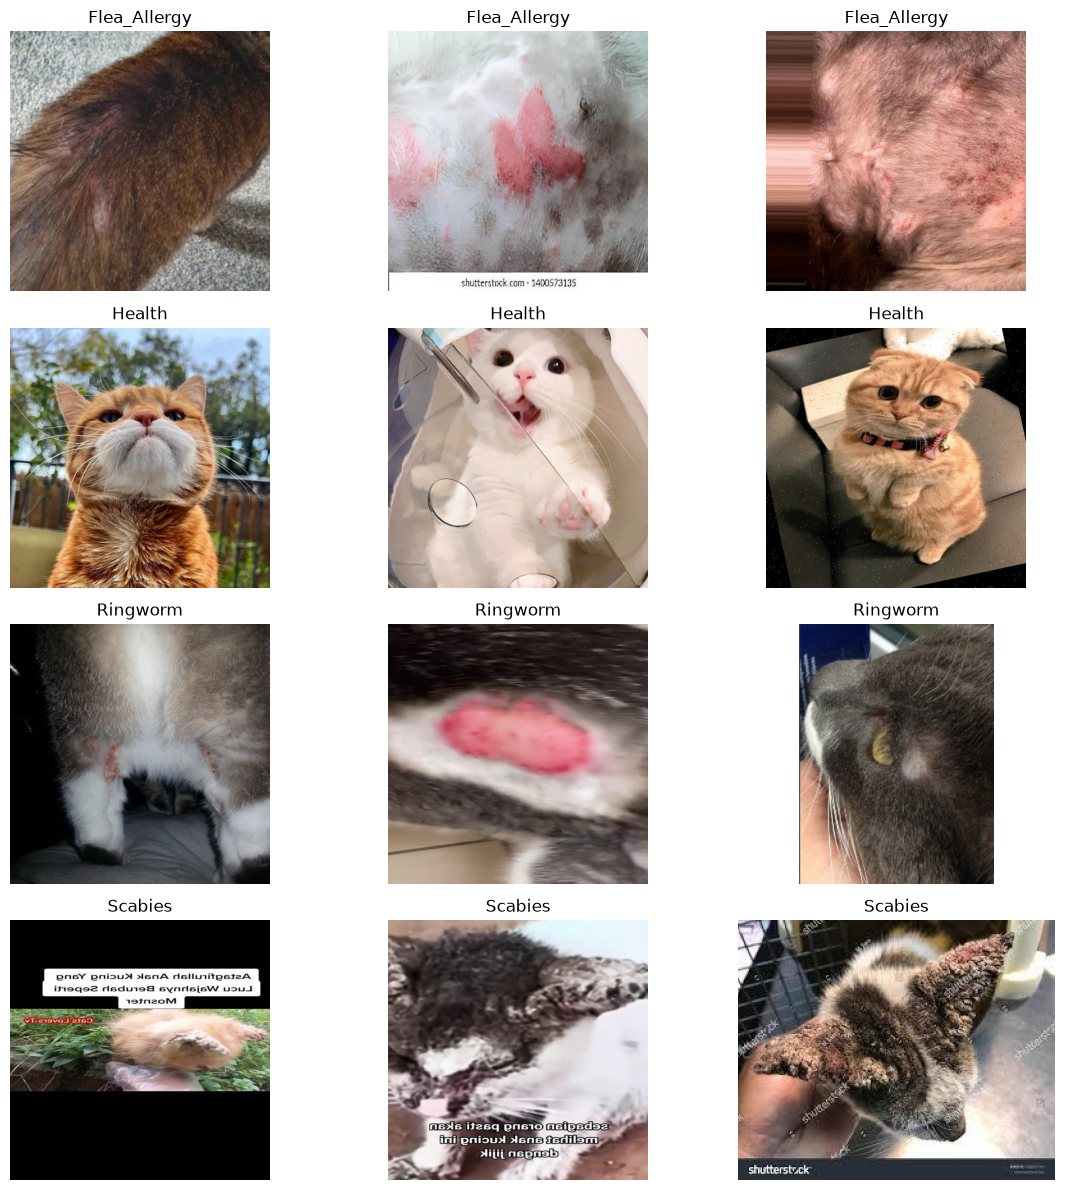

In [2]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = root / "kaggle"

classes = sorted([f for f in dataset_path.iterdir() if f.is_dir()])

fig, axes = plt.subplots(len(classes), 3, figsize=(12, 12))

for row, folder in enumerate(classes):

    images = list(folder.glob("*.jpg")) + \
             list(folder.glob("*.jpeg")) + \
             list(folder.glob("*.png"))

    samples = random.sample(images, 3)

    for col, img_path in enumerate(samples):

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(img)
        axes[row, col].set_title(folder.name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [3]:
import cv2

sizes = []

for folder in classes:

    for img_path in folder.iterdir():

        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

            img = cv2.imread(str(img_path))

            if img is not None:

                h, w = img.shape[:2]
                sizes.append((w, h))

unique_sizes = sorted(set(sizes))

print(f"Jumlah ukuran berbeda : {len(unique_sizes)}")

for w, h in unique_sizes:
    print(f"{w} x {h}")

Jumlah ukuran berbeda : 159
97 x 200
124 x 171
128 x 200
133 x 200
143 x 200
150 x 200
182 x 200
187 x 269
194 x 259
196 x 133
196 x 184
200 x 113
200 x 120
200 x 128
200 x 132
200 x 133
200 x 134
200 x 148
200 x 150
200 x 154
200 x 193
233 x 177
236 x 177
240 x 311
242 x 252
247 x 175
248 x 203
251 x 155
251 x 335
253 x 332
259 x 194
262 x 220
263 x 192
263 x 261
268 x 192
268 x 206
270 x 370
272 x 260
272 x 261
273 x 342
274 x 315
275 x 183
276 x 183
276 x 353
277 x 308
282 x 300
283 x 170
283 x 178
287 x 165
287 x 172
287 x 266
291 x 372
291 x 481
297 x 197
299 x 168
300 x 167
300 x 200
300 x 274
300 x 300
301 x 252
302 x 193
302 x 298
303 x 248
307 x 186
307 x 197
313 x 205
316 x 397
318 x 237
320 x 210
323 x 287
325 x 241
326 x 318
327 x 455
330 x 217
332 x 307
335 x 407
342 x 355
357 x 337
360 x 225
367 x 357
376 x 365
378 x 297
378 x 422
388 x 365
395 x 344
406 x 350
442 x 363
450 x 362
450 x 600
455 x 366
474 x 350
474 x 355
499 x 360
499 x 409
510 x 304
526 x 1139
531 x 297
53

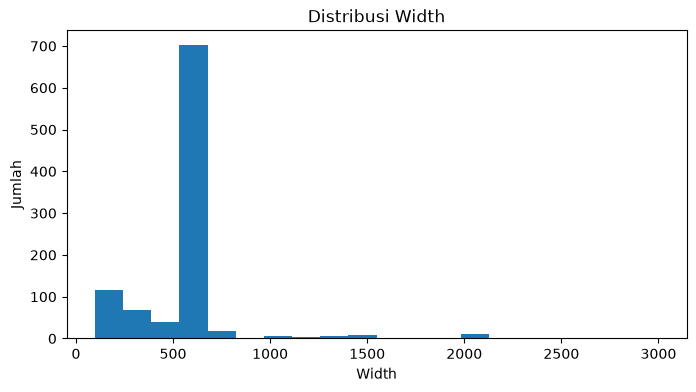

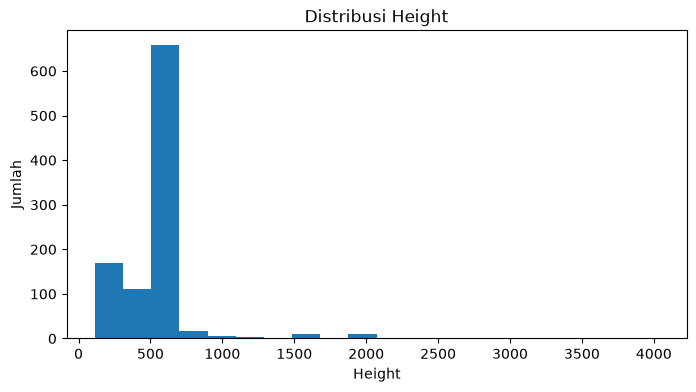

In [4]:
widths = []
heights = []

for folder in classes:

    for img_path in folder.iterdir():

        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

            img = cv2.imread(str(img_path))

            if img is not None:

                h, w = img.shape[:2]

                widths.append(w)
                heights.append(h)

plt.figure(figsize=(8,4))
plt.hist(widths, bins=20)
plt.title("Distribusi Width")
plt.xlabel("Width")
plt.ylabel("Jumlah")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(heights, bins=20)
plt.title("Distribusi Height")
plt.xlabel("Height")
plt.ylabel("Jumlah")
plt.show()

In [5]:
from PIL import Image

corrupt_images = []

for folder in classes:

    for img_path in folder.iterdir():

        try:
            img = Image.open(img_path)
            img.verify()

        except Exception:

            corrupt_images.append(img_path)

print("Jumlah gambar corrupt :", len(corrupt_images))


Jumlah gambar corrupt : 0


In [6]:
import hashlib

hashes = {}
duplicates = []

for folder in classes:

    for img_path in folder.iterdir():

        with open(img_path, "rb") as f:

            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hashes:

            duplicates.append((img_path, hashes[file_hash]))

        else:

            hashes[file_hash] = img_path

print("Jumlah duplicate :", len(duplicates))

if duplicates:
    for dup, ori in duplicates:
        print(f"{dup} == {ori}")

Jumlah duplicate : 0


# Cleaning

In [7]:
import hashlib

seen_hashes = {}
removed_duplicates = []

for folder in dataset_path.iterdir():

    if not folder.is_dir():
        continue

    for img_path in folder.iterdir():

        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in seen_hashes:

            removed_duplicates.append(img_path)
            img_path.unlink()

        else:

            seen_hashes[file_hash] = img_path

print(f"Total duplicate dihapus : {len(removed_duplicates)}")

Total duplicate dihapus : 0


In [8]:
from PIL import Image

converted = 0

for folder in dataset_path.iterdir():

    if not folder.is_dir():
        continue

    for img_path in list(folder.iterdir()):

        if img_path.suffix.lower() == ".jpg":
            continue

        if img_path.suffix.lower() not in [".jpeg", ".png", ".webp", ".bmp", ".tiff", ".gif"]:
            continue

        try:

            img = Image.open(img_path).convert("RGB")

            new_path = img_path.with_suffix(".jpg")

            img.save(new_path, quality=95)

            img_path.unlink()

            converted += 1

        except Exception as e:
            print(img_path, e)

print(f"Total gambar dikonversi : {converted}")

Total gambar dikonversi : 0


In [9]:
from collections import Counter

extensions = Counter()

for folder in dataset_path.iterdir():

    if not folder.is_dir():
        continue

    for img_path in folder.iterdir():

        extensions[img_path.suffix.lower()] += 1

print("Format file setelah cleaning:")

for ext, total in sorted(extensions.items()):
    print(f"{ext} : {total}")

Format file setelah cleaning:
.jpg : 983


# Split data

In [10]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil

dataset_path = root / "kaggle"
output_path = root / "dataset"

train_path = output_path / "train"
test_path = output_path / "test"

# Hapus hasil split lama jika ada
if output_path.exists():
    shutil.rmtree(output_path)

train_path.mkdir(parents=True)
test_path.mkdir(parents=True)

RANDOM_STATE = 42

for class_dir in sorted(dataset_path.iterdir()):

    if not class_dir.is_dir():
        continue

    images = []

    for ext in ("*.jpg", "*.jpeg", "*.png"):
        images.extend(class_dir.glob(ext))

    train_imgs, test_imgs = train_test_split(
        images,
        test_size=0.2,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    (train_path / class_dir.name).mkdir(exist_ok=True)
    (test_path / class_dir.name).mkdir(exist_ok=True)

    for img in train_imgs:
        shutil.copy2(img, train_path / class_dir.name / img.name)

    for img in test_imgs:
        shutil.copy2(img, test_path / class_dir.name / img.name)

print("Split dataset selesai.")

Split dataset selesai.


# Offline Augmentation

melakukan augmentasi pada data train dengan sebanyak 

'random.randint(1,3)'

caranya dgn memilih secara acak gambar, lalu mnetransformasi secara acak. menyimpannya dan mengulanginya sebanyak 1000 gambar per kelas

In [11]:
import os
import cv2
import random
import numpy as np
import albumentations as A
from pathlib import Path

train_path = root / "dataset" / "train"
augmented_path = root / "dataset" / "train_augmented"

TARGET_PER_CLASS = 1000
IMG_SIZE = 224

medical_augment = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=30,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.GaussianBlur(
        blur_limit=(3,5),
        p=0.3
    ),

    A.RandomResizedCrop(
        size=(224,224),
        scale=(0.9,1.0),
        p=0.3
    ),

    A.CLAHE(
        clip_limit=2.0,
        p=0.3
    ),

    A.GaussNoise(
        std_range=(0.02,0.08),
        p=0.3
    )

])

print("Pipeline augmentasi siap.")

Pipeline augmentasi siap.


In [12]:
import shutil

if augmented_path.exists():
    shutil.rmtree(augmented_path)

augmented_path.mkdir(parents=True)

for class_dir in sorted(train_path.iterdir()):

    if not class_dir.is_dir():
        continue

    print(f"\nMemproses {class_dir.name}")

    save_dir = augmented_path / class_dir.name
    save_dir.mkdir(parents=True)

    images = []

    for ext in ("*.jpg","*.jpeg","*.png"):
        images.extend(class_dir.glob(ext))

    # Copy gambar asli
    for img in images:
        shutil.copy2(img, save_dir / img.name)

    total = len(list(save_dir.glob("*")))

    print(f"Gambar asli : {total}")

    counter = 1

    while total < TARGET_PER_CLASS:

        img_path = random.choice(images)

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        transform_times = random.randint(1,3)

        augmented = image.copy()

        for _ in range(transform_times):

            augmented = medical_augment(image=augmented)["image"]

        filename = f"aug_{counter:05d}.jpg"

        save_path = save_dir / filename

        cv2.imwrite(
            str(save_path),
            cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        )

        counter += 1
        total += 1

    print(f"Total akhir : {total}")


Memproses Flea_Allergy
Gambar asli : 192
Total akhir : 1000

Memproses Health
Gambar asli : 196
Total akhir : 1000

Memproses Ringworm
Gambar asli : 197
Total akhir : 1000

Memproses Scabies
Gambar asli : 200
Total akhir : 1000


# data generator

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

TRAIN_DIR = root / "dataset" / "train_augmented"
TEST_DIR = root / "dataset" / "test"

BATCH_SIZE = 32
IMG_SIZE = (224,224)

datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.2

)

test_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input

)

In [14]:
train_generator = datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training",

    shuffle=True,

    seed=42

)

Found 3200 images belonging to 4 classes.


In [15]:
validation_generator = datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation",

    shuffle=False,

    seed=42

)

Found 800 images belonging to 4 classes.


In [16]:
test_generator = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=IMG_SIZE,

    batch_size=1,

    class_mode="categorical",

    shuffle=False

)

Found 198 images belonging to 4 classes.


In [17]:
print(train_generator.class_indices)

print("Training :", train_generator.samples)

print("Validation :", validation_generator.samples)

print("Testing :", test_generator.samples)

{'Flea_Allergy': 0, 'Health': 1, 'Ringworm': 2, 'Scabies': 3}
Training : 3200
Validation : 800
Testing : 198


# effecientnetB0

In [18]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import AdamW

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

x = BatchNormalization()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

NUM_CLASSES = train_generator.num_classes

outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,417,063 (16.85 MB)

 Trainable params: 4,371,968 (16.68 MB)

 Non-trainable params: 45,095 (176.16 KB)

## stage 1

In [19]:
# feature extracion stage 1

from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

base_model.trainable = False

model.compile(

    optimizer=AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),

    loss=CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=["accuracy"]

)

In [20]:
# callback stage 1

callbacks_stage1 = [

    EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True,

        verbose=1

    ),

    ModelCheckpoint(

        filepath="stage1_best.keras",

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    )

]

In [21]:
#trainning stage 1
history_stage1 = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=15,

    callbacks=callbacks_stage1,

    verbose=1

)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7428 - loss: 0.8780
Epoch 1: val_accuracy improved from None to 0.92750, saving model to stage1_best.keras

Epoch 1: finished saving model to stage1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 100s 812ms/step - accuracy: 0.7428 - loss: 0.8780 - val_accuracy: 0.9275 - val_loss: 0.6115
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.8594 - loss: 0.6652
Epoch 2: val_accuracy improved from 0.92750 to 0.95125, saving model to stage1_best.keras

Epoch 2: finished saving model to stage1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 788ms/step - accuracy: 0.8594 - loss: 0.6652 - val_accuracy: 0.9513 - val_loss: 0.5036
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9006 - loss: 0.5973
Epoch 3: val_accuracy improved from 0.95125 to 0.97625, saving model to stage1_best.keras

Epoch 3: finished saving model to stage1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 788ms/step - accuracy: 0.9006 - loss

## Stage 2

In [22]:
print("STAGE 2 : FINE TUNING")


model.load_weights("stage1_best.keras")

base_model.trainable = True

freeze_until = int(len(base_model.layers) * 0.6)

for i, layer in enumerate(base_model.layers):

    layer.trainable = i >= freeze_until

STAGE 2 : FINE TUNING


In [23]:
model.compile(

    optimizer=AdamW(

        learning_rate=1e-5,

        weight_decay=1e-4

    ),

    loss=CategoricalCrossentropy(

        label_smoothing=0.1

    ),

    metrics=["accuracy"]

)

In [24]:
callbacks_stage2 = [

    EarlyStopping(

        monitor="val_loss",

        patience=10,

        restore_best_weights=True,

        verbose=1

    ),

    ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=5,

        min_lr=1e-7,

        verbose=1

    ),

    ModelCheckpoint(

        filepath="stage2_best.keras",

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    )

]

In [25]:
import pickle
history_stage2 = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=50,

    callbacks=callbacks_stage2,

    verbose=1

)

with open("history_stage1.pkl", "wb") as f:
    pickle.dump(history_stage1.history, f)

with open("history_stage2.pkl", "wb") as f:
    pickle.dump(history_stage2.history, f)

print("Training history berhasil disimpan.")

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8491 - loss: 0.6656
Epoch 1: val_accuracy improved from None to 0.97875, saving model to stage2_best.keras

Epoch 1: finished saving model to stage2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.8491 - loss: 0.6656 - val_accuracy: 0.9787 - val_loss: 0.4262 - learning_rate: 1.0000e-05
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8906 - loss: 0.5907
Epoch 2: val_accuracy did not improve from 0.97875
100/100 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8906 - loss: 0.5907 - val_accuracy: 0.9675 - val_loss: 0.4481 - learning_rate: 1.0000e-05
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9194 - loss: 0.5452
Epoch 3: val_accuracy did not improve from 0.97875
100/100 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9194 - loss: 0.5452 - val_accuracy: 0.9663 - val_loss: 0.4526 - learning_rate: 1.0000e-05
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.

# model evalution

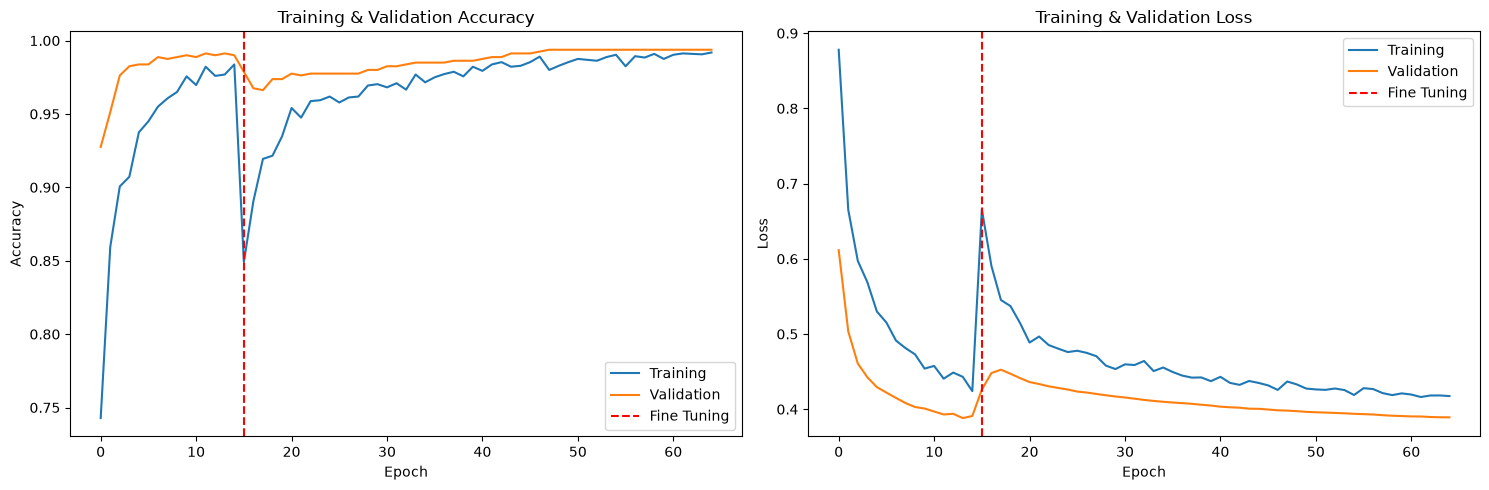

In [26]:
import matplotlib.pyplot as plt

stage1_end = len(history_stage1.history["accuracy"])

total_acc = (
    history_stage1.history["accuracy"] +
    history_stage2.history["accuracy"]
)

total_val_acc = (
    history_stage1.history["val_accuracy"] +
    history_stage2.history["val_accuracy"]
)

total_loss = (
    history_stage1.history["loss"] +
    history_stage2.history["loss"]
)

total_val_loss = (
    history_stage1.history["val_loss"] +
    history_stage2.history["val_loss"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(total_acc, label="Training")
axes[0].plot(total_val_acc, label="Validation")
axes[0].axvline(
    stage1_end,
    color="red",
    linestyle="--",
    label="Fine Tuning"
)

axes[0].set_title("Training & Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(total_loss, label="Training")
axes[1].plot(total_val_loss, label="Validation")
axes[1].axvline(
    stage1_end,
    color="red",
    linestyle="--",
    label="Fine Tuning"
)

axes[1].set_title("Training & Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
model.load_weights("stage2_best.keras")

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print("=" * 60)

198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9040 - loss: 0.5563
Test Loss     : 0.5563
Test Accuracy : 0.9040


In [29]:
from sklearn.metrics import classification_report
import numpy as np

test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step
              precision    recall  f1-score   support

Flea_Allergy     0.8519    0.9388    0.8932        49
      Health     0.9388    0.9388    0.9388        49
    Ringworm     0.9302    0.8000    0.8602        50
     Scabies     0.9038    0.9400    0.9216        50

    accuracy                         0.9040       198
   macro avg     0.9062    0.9044    0.9034       198
weighted avg     0.9063    0.9040    0.9033       198



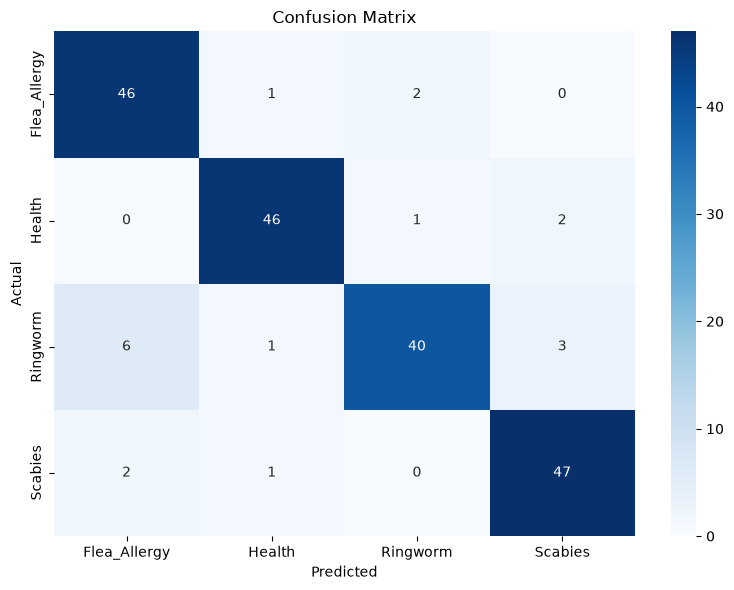

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [31]:
model.save("cat_skin_efficientnetb0.keras")

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [32]:
import pickle

with open("history_stage1.pkl", "wb") as f:
    pickle.dump(history_stage1.history, f)

with open("history_stage2.pkl", "wb") as f:
    pickle.dump(history_stage2.history, f)

print("History berhasil disimpan.")

History berhasil disimpan.
